> **Note.** This notebook uses hand-transcribed technology timelines. The AURIS-based, full cause-to-effect analysis (scenario prices, technology economics, NPV decisions, fuels, CO2, 15-minute electricity demand) is in `investment_decision_chain_analysis.ipynb`.

# Technology investment decisions vs. electricity demand

Combines the cement and steel plant simulation results to compare **annual electricity demand (day-ahead + aFRR, MWh)** across the 8 investment decisions:

- 6 risk-neutral beliefs (Technologiemix, FokusStrom, FokusH2, NachfrageNiedrig, HoheNachfrage, AktuellePolitiken) -- each evaluated in its own matching market
- 2 risk-averse strategies (WC Mean, WC Tail Risk) -- each a *fixed* technology path, evaluated under all 6 possible market realizations

Source data: `data/output/cement_results/` and `data/output/steel_results/` (the compressed per-case `summary_indicators.csv.zst` files, which already carry each plant's annual `total_DA_electricity_MWh` and `total_afrr_energy_activated_MWh` -- no need to re-scan the full 15-min dispatch time series for an annual-total view).

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the FLEXIMOD project root.")


PROJECT_ROOT = find_project_root()
CEMENT_RESULTS = PROJECT_ROOT / "data" / "output" / "cement_results"
STEEL_RESULTS = PROJECT_ROOT / "data" / "output" / "steel_results"
STEEL_FOLDER_SUFFIXES = ("_electrified_steel_rule_based", "_electrified_steel")
SIM_YEARS = [2030, 2035, 2040, 2045]

MARKET_FAMILIES = {
    "Technologiemix": "technologiemix",
    "FokusStrom": "fokusstrom",
    "FokusH2": "fokusH2",
    "NachfrageNiedrig": "niedrigenachfrage",
    "HoheNachfrage": "hohenachfrage",
    "AktuellePolitiken": "aktuellepolitiken",
}
RN_DECISIONS = list(MARKET_FAMILIES)
RA_DECISIONS = ["WCMean", "WCTail"]


## Investment-decision timelines

Transcribed verbatim from the investor-provided tables: for each plant, which technology/route is active from which year, under each decision.

In [2]:
# Cement: plant_id -> {decision: "year:route|year:route..."}
CEMENT_RN_TIMELINE = {
    "P100000124212": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2032:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000124253": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2037:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000124254": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2034:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000124277": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2032:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000124384": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000124709": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2035:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000124753": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2032:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000124810": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2034:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000124839": {"Technologiemix": "2025:R8|2030:R4|2031:R8", "FokusStrom": "2025:R8|2030:R4|2031:R8", "FokusH2": "2025:R8|2030:R4|2031:R15A|2043:R8", "NachfrageNiedrig": "2025:R8|2030:R4|2031:R8", "HoheNachfrage": "2025:R8|2030:R4|2031:R8", "AktuellePolitiken": "2025:R8|2030:R4|2031:R8"},
    "P100000125763": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125764": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125765": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2034:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125767": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2036:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125768": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2032:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125769": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125770": {"Technologiemix": "2025:R8|2029:R9|2030:R8", "FokusStrom": "2025:R8|2029:R9|2030:R8", "FokusH2": "2025:R8|2029:R9|2030:R15A|2043:R8", "NachfrageNiedrig": "2025:R8|2029:R9|2030:R8", "HoheNachfrage": "2025:R8|2029:R9|2030:R8", "AktuellePolitiken": "2025:R8|2029:R9|2030:R8"},
    "P100000125773": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125774": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125775": {"Technologiemix": "2025:R8|2028:R9|2029:R8", "FokusStrom": "2025:R8|2028:R9|2029:R8", "FokusH2": "2025:R8|2028:R9|2029:R15A|2043:R8", "NachfrageNiedrig": "2025:R8|2028:R9|2029:R8", "HoheNachfrage": "2025:R8|2028:R9|2029:R8", "AktuellePolitiken": "2025:R8|2028:R9|2029:R8"},
    "P100000125776": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125777": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2032:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125782": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125784": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2035:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125785": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125786": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125787": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125788": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125789": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125790": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125792": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2036:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125793": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2033:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
    "P100000125796": {"Technologiemix": "2025:R8", "FokusStrom": "2025:R8", "FokusH2": "2025:R8|2035:R15A|2043:R8", "NachfrageNiedrig": "2025:R8", "HoheNachfrage": "2025:R8", "AktuellePolitiken": "2025:R8"},
}


In [3]:
# Cement: plant_id -> {"WCMean"/"WCTail": "year: route; year: route..."}
CEMENT_RA_TIMELINE = {
    "P100000124212": {"WCMean": "2025: R8; 2033: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000124253": {"WCMean": "2025: R8; 2040: R11a; 2042: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000124254": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000124277": {"WCMean": "2025: R8; 2033: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000124384": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000124709": {"WCMean": "2025: R8; 2038: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000124753": {"WCMean": "2025: R8; 2034: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000124810": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000124839": {"WCMean": "2025: R8; 2030: R4; 2031: R15a; 2043: R8", "WCTail": "2025: R15a; 2030: R4; 2031: R11a; 2044: R8"},
    "P100000125763": {"WCMean": "2025: R8; 2034: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125764": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125765": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125767": {"WCMean": "2025: R8; 2039: R11a; 2042: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125768": {"WCMean": "2025: R8; 2034: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125769": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125770": {"WCMean": "2025: R8; 2029: R9; 2030: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2029: R9; 2030: R11a; 2044: R8"},
    "P100000125773": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125774": {"WCMean": "2025: R8; 2034: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125775": {"WCMean": "2025: R8; 2028: R9; 2029: R8; 2034: R11a; 2043: R8", "WCTail": "2025: R15a; 2028: R9; 2029: R15a; 2044: R8"},
    "P100000125776": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125777": {"WCMean": "2025: R8; 2034: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125782": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125784": {"WCMean": "2025: R8; 2038: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125785": {"WCMean": "2025: R8", "WCTail": "2025: R8; 2032: R11a; 2043: R8"},
    "P100000125786": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125787": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125788": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125789": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125790": {"WCMean": "2025: R8; 2034: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125792": {"WCMean": "2025: R8; 2039: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125793": {"WCMean": "2025: R8; 2035: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
    "P100000125796": {"WCMean": "2025: R8; 2038: R11a; 2043: R8", "WCTail": "2025: R15a; 2044: R8"},
}


In [4]:
# Steel: plant_id -> {decision: "year: TECHNOLOGY NAME; year: TECHNOLOGY NAME..."}
STEEL_RN_TIMELINE = {
    "P100000120421": {
        "Technologiemix": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2032: BF BOF HYDROGEN ELECTROLYSER",
        "FokusStrom": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2032: BF BOF HYDROGEN ELECTROLYSER",
        "FokusH2": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "NachfrageNiedrig": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2030: BF BOF HYDROGEN ELECTROLYSER",
        "HoheNachfrage": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI BOF HYDROGEN ELECTROLYSER; 2046: BF BOF HYDROGEN ELECTROLYSER",
        "AktuellePolitiken": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120422": {
        "Technologiemix": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2032: BF BOF HYDROGEN ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "FokusStrom": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2033: BF BOF HYDROGEN ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "FokusH2": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "NachfrageNiedrig": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2030: BF BOF HYDROGEN ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "HoheNachfrage": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2030: BF BOF HYDROGEN ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "AktuellePolitiken": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2040: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
    },
    "P100000120423": {
        "Technologiemix": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2027: DRI EAF HYDROGEN ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "FokusStrom": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2029: BF BOF HYDROGEN ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "FokusH2": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2031: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "NachfrageNiedrig": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2027: DRI EAF HYDROGEN ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "HoheNachfrage": "2025: BF BOF HYDROGEN ELECTROLYSER; 2027: DRI EAF HYDROGEN ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "AktuellePolitiken": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: DRI EAF HYDROGEN ELECTROLYSER",
    },
    "P100000120424": {
        "Technologiemix": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2044: BF BOF HYDROGEN ELECTROLYSER",
        "FokusStrom": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2044: BF BOF HYDROGEN ELECTROLYSER",
        "FokusH2": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "NachfrageNiedrig": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "HoheNachfrage": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI EAF HYDROGEN ELECTROLYSER; 2046: BF BOF HYDROGEN ELECTROLYSER",
        "AktuellePolitiken": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120425": {
        "Technologiemix": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "FokusStrom": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "FokusH2": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "NachfrageNiedrig": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "HoheNachfrage": "2025: BF BOF HYDROGEN ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "AktuellePolitiken": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120426": {
        "Technologiemix": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "FokusStrom": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "FokusH2": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "NachfrageNiedrig": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "HoheNachfrage": "2025: BF BOF HYDROGEN ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "AktuellePolitiken": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120427": {
        "Technologiemix": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2033: BF BOF HYDROGEN ELECTROLYSER",
        "FokusStrom": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2033: BF BOF HYDROGEN ELECTROLYSER",
        "FokusH2": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "NachfrageNiedrig": "2025: BF BOF HYDROGEN ELECTROLYSER; 2026: DRI EAF HYDROGEN ELECTROLYSER; 2046: BF BOF HYDROGEN ELECTROLYSER",
        "HoheNachfrage": "2025: BF BOF HYDROGEN ELECTROLYSER; 2026: DRI EAF HYDROGEN ELECTROLYSER; 2046: BF BOF HYDROGEN ELECTROLYSER",
        "AktuellePolitiken": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120428": {
        "Technologiemix": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2030: DRI EAF HYDROGEN ELECTROLYSER",
        "FokusStrom": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2030: DRI EAF HYDROGEN ELECTROLYSER",
        "FokusH2": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2030: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2031: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "NachfrageNiedrig": "2025: BF BOF HYDROGEN ELECTROLYSER; 2030: DRI EAF HYDROGEN ELECTROLYSER",
        "HoheNachfrage": "2025: BF BOF HYDROGEN ELECTROLYSER; 2030: DRI EAF HYDROGEN ELECTROLYSER",
        "AktuellePolitiken": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2030: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2035: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2049: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120432": {
        "Technologiemix": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2028: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2044: BF BOF HYDROGEN ELECTROLYSER",
        "FokusStrom": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2028: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2044: BF BOF HYDROGEN ELECTROLYSER",
        "FokusH2": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2028: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "NachfrageNiedrig": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2027: DRI EAF HYDROGEN ELECTROLYSER; 2047: BF BOF HYDROGEN ELECTROLYSER",
        "HoheNachfrage": "2025: BF BOF HYDROGEN ELECTROLYSER; 2027: DRI EAF HYDROGEN ELECTROLYSER; 2047: BF BOF HYDROGEN ELECTROLYSER",
        "AktuellePolitiken": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2039: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER",
    },
}


In [5]:
# Steel: plant_id -> {"WCMean"/"WCTail": "year: TECHNOLOGY NAME; ..."}
STEEL_RA_TIMELINE = {
    "P100000120421": {
        "WCMean": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "WCTail": "2025: BF BOF HYDROGEN EXTERNAL; 2026: DRI BOF HYDROGEN EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120422": {
        "WCMean": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "WCTail": "2025: BF BOF HYDROGEN EXTERNAL; 2045: DRI EAF HYDROGEN ELECTROLYSER",
    },
    "P100000120423": {
        "WCMean": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2031: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
        "WCTail": "2025: BF BOF HYDROGEN EXTERNAL; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2028: BF BOF HYDROGEN EXTERNAL; 2043: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: DRI EAF HYDROGEN ELECTROLYSER",
    },
    "P100000120424": {
        "WCMean": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "WCTail": "2025: BF BOF HYDROGEN EXTERNAL; 2026: DRI EAF HYDROGEN EXTERNAL; 2027: BF BOF HYDROGEN EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120425": {
        "WCMean": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "WCTail": "2025: BF BOF HYDROGEN EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120426": {
        "WCMean": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "WCTail": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2045: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120427": {
        "WCMean": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2040: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "WCTail": "2025: BF BOF HYDROGEN EXTERNAL; 2026: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: BF BOF HYDROGEN EXTERNAL; 2040: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2049: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120428": {
        "WCMean": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2030: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2035: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2049: BF BOF HYDROGEN ELECTROLYSER",
        "WCTail": "2025: BF BOF HYDROGEN EXTERNAL; 2030: DRI EAF HYDROGEN EXTERNAL; 2031: BF BOF HYDROGEN EXTERNAL; 2039: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2049: BF BOF HYDROGEN ELECTROLYSER",
    },
    "P100000120432": {
        "WCMean": "2025: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2028: BF BOF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2042: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2045: BF BOF HYDROGEN ELECTROLYSER",
        "WCTail": "2025: BF BOF HYDROGEN EXTERNAL; 2027: DRI EAF HYBRID HYDROGEN NATURAL GAS EXTERNAL; 2028: BF BOF HYDROGEN EXTERNAL; 2043: BF BOF HYBRID HYDROGEN NATURAL GAS ELECTROLYSER; 2047: BF BOF HYDROGEN ELECTROLYSER",
    },
}


## Route resolution + case lookup

Cement routes are already short codes (`R8`, `R11a`, ...). Steel routes are written out (`BF BOF HYDROGEN EXTERNAL`) and map onto the simulated folder names as a lowercase, underscore-joined slug.

In [6]:
def normalize_cement_route(route: str) -> str:
    match = re.match(r"^(R\d+)([a-zA-Z]?)$", route.strip())
    if not match:
        raise ValueError(f"Unrecognised cement route code: {route!r}")
    number, suffix = match.groups()
    return number + suffix.lower()


def normalize_steel_route(route: str) -> str:
    return route.strip().lower().replace(" ", "_")


def parse_timeline(timeline: str, sep: str, normalize) -> list[tuple[int, str]]:
    segments = []
    for part in timeline.split(sep):
        year_str, route_str = part.split(":", 1)
        segments.append((int(year_str.strip()), normalize(route_str)))
    segments.sort(key=lambda seg: seg[0])
    return segments


def route_at_year(segments: list[tuple[int, str]], year: int) -> str:
    idx = max(i for i, (start_year, _) in enumerate(segments) if start_year <= year)
    return segments[idx][1]


In [7]:
_summary_cache: dict[tuple[str, str, int, str], pd.DataFrame | None] = {}


def find_case_folder(sector: str, family: str, year: int, route: str) -> Path | None:
    if sector == "cement":
        folder = CEMENT_RESULTS / f"{family}_{year}_{route}_electrified_cement_rule_based"
        return folder if folder.exists() else None
    for suffix in STEEL_FOLDER_SUFFIXES:
        folder = STEEL_RESULTS / f"{family}_{year}_{route}{suffix}"
        if folder.exists():
            return folder
    return None


def load_summary(sector: str, family: str, year: int, route: str) -> pd.DataFrame | None:
    key = (sector, family, year, route)
    if key in _summary_cache:
        return _summary_cache[key]
    folder = find_case_folder(sector, family, year, route)
    if folder is None:
        print(f"  WARNING: no case folder for {sector} {family}_{year}_{route}")
        _summary_cache[key] = None
        return None
    df = pd.read_csv(
        folder / "summary_indicators.csv.zst",
        compression="zstd",
        usecols=[
            "plant_name",
            "total_DA_electricity_MWh",
            "total_afrr_energy_activated_MWh",
            "total_electricity_consumption_MWh",
            "total_hydrogen_consumption_MWh",
            "total_natural_gas_consumption_MWh",
            "total_coal_consumption_MWh",
        ],
    )
    _summary_cache[key] = df
    return df


CARRIER_COLUMNS = {
    "electricity": "total_electricity_consumption_MWh",
    "hydrogen": "total_hydrogen_consumption_MWh",
    "natural_gas": "total_natural_gas_consumption_MWh",
    "coal": "total_coal_consumption_MWh",
}


def plant_annual_row(sector: str, family: str, year: int, route: str, plant_id: str) -> pd.Series | None:
    df = load_summary(sector, family, year, route)
    if df is None:
        return None
    match = df[df["plant_name"] == f"{plant_id}_{route}"]
    if match.empty:
        print(f"  WARNING: {plant_id}_{route} not found in {sector} {family}_{year}_{route}")
        return None
    return match.iloc[0]


def plant_annual_demand(sector: str, family: str, year: int, route: str, plant_id: str) -> tuple[float, float] | None:
    row = plant_annual_row(sector, family, year, route, plant_id)
    if row is None:
        return None
    return float(row["total_DA_electricity_MWh"]), float(row["total_afrr_energy_activated_MWh"])


## Aggregate: sector-wide annual demand per decision / market / year

For every plant in a sector, resolve which technology is active in each year under a given decision, pull that plant's simulated annual DA + aFRR MWh, and sum across all plants in the sector.

In [8]:
SECTOR_CONFIG = {
    "cement": {
        "rn_timeline": CEMENT_RN_TIMELINE,
        "ra_timeline": CEMENT_RA_TIMELINE,
        "rn_sep": "|",
        "ra_sep": ";",
        "normalize": normalize_cement_route,
    },
    "steel": {
        "rn_timeline": STEEL_RN_TIMELINE,
        "ra_timeline": STEEL_RA_TIMELINE,
        "rn_sep": ";",
        "ra_sep": ";",
        "normalize": normalize_steel_route,
    },
}


def sector_annual_demand(sector: str, decision: str, market_family: str, year: int) -> tuple[float, float]:
    cfg = SECTOR_CONFIG[sector]
    is_ra = decision in RA_DECISIONS
    timeline_data = cfg["ra_timeline"] if is_ra else cfg["rn_timeline"]
    sep = cfg["ra_sep"] if is_ra else cfg["rn_sep"]

    total_da = 0.0
    total_afrr = 0.0
    for plant_id, timelines in timeline_data.items():
        segments = parse_timeline(timelines[decision], sep, cfg["normalize"])
        route = route_at_year(segments, year)
        result = plant_annual_demand(sector, market_family, year, route, plant_id)
        if result is None:
            continue
        da, afrr = result
        total_da += da
        total_afrr += afrr
    return total_da, total_afrr


def sector_annual_carriers(sector: str, decision: str, market_family: str, year: int) -> dict[str, float]:
    """Sum each energy carrier's annual consumption (MWh) across every plant in the sector."""
    cfg = SECTOR_CONFIG[sector]
    is_ra = decision in RA_DECISIONS
    timeline_data = cfg["ra_timeline"] if is_ra else cfg["rn_timeline"]
    sep = cfg["ra_sep"] if is_ra else cfg["rn_sep"]

    totals = dict.fromkeys(CARRIER_COLUMNS, 0.0)
    for plant_id, timelines in timeline_data.items():
        segments = parse_timeline(timelines[decision], sep, cfg["normalize"])
        route = route_at_year(segments, year)
        row = plant_annual_row(sector, market_family, year, route, plant_id)
        if row is None:
            continue
        for carrier, column in CARRIER_COLUMNS.items():
            totals[carrier] += float(row[column])
    return totals


In [9]:
records = []
for sector in ("cement", "steel"):
    # Risk-neutral: each decision matched to its own market.
    for decision in RN_DECISIONS:
        market_family = MARKET_FAMILIES[decision]
        for year in SIM_YEARS:
            da, afrr = sector_annual_demand(sector, decision, market_family, year)
            records.append({
                "sector": sector,
                "decision": decision,
                "decision_type": "risk-neutral",
                "market": decision,
                "year": year,
                "day_ahead_MWh": da,
                "afrr_MWh": afrr,
                "total_MWh": da + afrr,
            })
    # Risk-averse: each fixed decision evaluated under every market.
    for decision in RA_DECISIONS:
        for market_label, market_family in MARKET_FAMILIES.items():
            for year in SIM_YEARS:
                da, afrr = sector_annual_demand(sector, decision, market_family, year)
                records.append({
                    "sector": sector,
                    "decision": decision,
                    "decision_type": "risk-averse",
                    "market": market_label,
                    "year": year,
                    "day_ahead_MWh": da,
                    "afrr_MWh": afrr,
                    "total_MWh": da + afrr,
                })

demand = pd.DataFrame(records)
print(f"{len(demand):,} rows")
demand.head()


144 rows


,sector,decision,decision_type,market,year,day_ahead_MWh,afrr_MWh,total_MWh
0,cement,Technologiemix,risk-neutral,Technologiemix,2030,9.082320e+07,3563388.847,9.438659e+07
1,cement,Technologiemix,risk-neutral,Technologiemix,2035,1.006509e+08,2114972.284,1.027658e+08
2,cement,Technologiemix,risk-neutral,Technologiemix,2040,1.042805e+08,1821062.285,1.061015e+08
3,cement,Technologiemix,risk-neutral,Technologiemix,2045,1.075971e+08,1819907.979,1.094170e+08
4,cement,FokusStrom,risk-neutral,FokusStrom,2030,9.074739e+07,3639197.407,9.438659e+07


## Chart 1 -- Risk-neutral decisions: annual demand over time

Each line is "if the investor had believed in this scenario and acted risk-neutral" -- technology matched to, and evaluated in, its own market.

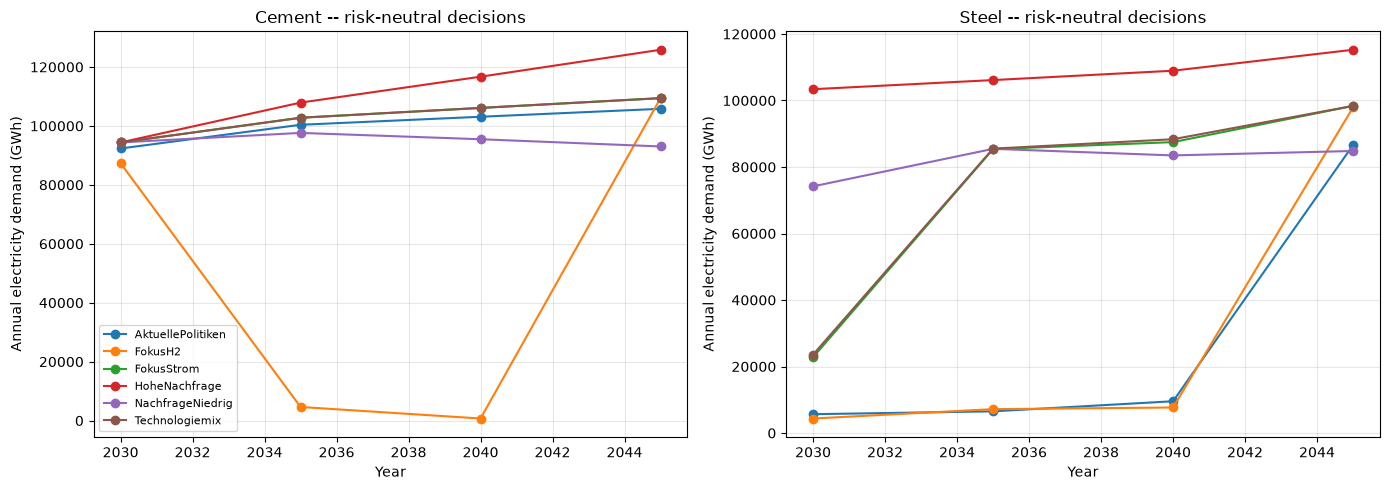

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, sector in zip(axes, ("cement", "steel")):
    subset = demand[(demand["sector"] == sector) & (demand["decision_type"] == "risk-neutral")]
    for decision, group in subset.groupby("decision"):
        group = group.sort_values("year")
        ax.plot(group["year"], group["total_MWh"] / 1000, marker="o", label=decision)
    ax.set_title(f"{sector.capitalize()} -- risk-neutral decisions")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual electricity demand (GWh)")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc="best")
fig.tight_layout()
plt.show()


**Key findings**

- Cement's six risk-neutral beliefs barely move total electricity demand: all fall in an 87-126 GWh/year band throughout 2030-2045. The technology choice matters far less for cement's electricity draw than for steel's, since most cement routes stay electricity-and-coal based.
- Steel diverges sharply at 2030 -- demand ranges from 4.4 GWh (FokusH2) to 103 GWh (HoheNachfrage), a ~24x spread -- because these beliefs assume very different early-2030s production ramp-ups. By 2045 all six converge to 85-115 GWh as the underlying demand assumptions equalize.
- HoheNachfrage is the highest-demand belief in both sectors at every year checked; NachfrageNiedrig is the most conservative for cement -- consistent with their names (high- vs low-demand scenarios).

## Energy demand by carrier

Total electricity procured (day-ahead + aFRR) only shows the size of the electricity bill. The technology choice is really a choice about **fuel mix** -- how much of the plant's annual energy comes from grid electricity vs. hydrogen vs. natural gas vs. coal. That mix is what actually shows the decarbonisation pathway, so it's aggregated here separately from the market-price-driven demand view above.

In [11]:
carrier_records = []
for sector in ("cement", "steel"):
    for decision in RN_DECISIONS:
        market_family = MARKET_FAMILIES[decision]
        for year in SIM_YEARS:
            totals = sector_annual_carriers(sector, decision, market_family, year)
            for carrier, mwh in totals.items():
                carrier_records.append({
                    "sector": sector,
                    "decision": decision,
                    "decision_type": "risk-neutral",
                    "market": decision,
                    "year": year,
                    "carrier": carrier,
                    "MWh": mwh,
                })
    for decision in RA_DECISIONS:
        for market_label, market_family in MARKET_FAMILIES.items():
            for year in SIM_YEARS:
                totals = sector_annual_carriers(sector, decision, market_family, year)
                for carrier, mwh in totals.items():
                    carrier_records.append({
                        "sector": sector,
                        "decision": decision,
                        "decision_type": "risk-averse",
                        "market": market_label,
                        "year": year,
                        "carrier": carrier,
                        "MWh": mwh,
                    })

carriers = pd.DataFrame(carrier_records)
print(f"{len(carriers):,} rows")
carriers.head()


576 rows


,sector,decision,decision_type,market,year,carrier,MWh
0,cement,Technologiemix,risk-neutral,Technologiemix,2030,electricity,9.438659e+07
1,cement,Technologiemix,risk-neutral,Technologiemix,2030,hydrogen,0.000000e+00
2,cement,Technologiemix,risk-neutral,Technologiemix,2030,natural_gas,2.164206e+05
3,cement,Technologiemix,risk-neutral,Technologiemix,2030,coal,6.148892e+06
4,cement,Technologiemix,risk-neutral,Technologiemix,2035,electricity,1.027658e+08


## Chart 2 -- Risk-neutral decisions: fuel mix over time

One panel per belief, stacked area of annual carrier consumption (electricity / hydrogen / natural gas / coal), technology matched to and evaluated in its own market -- same decisions as Chart 1, now decomposed by fuel instead of collapsed into one electricity-demand number.

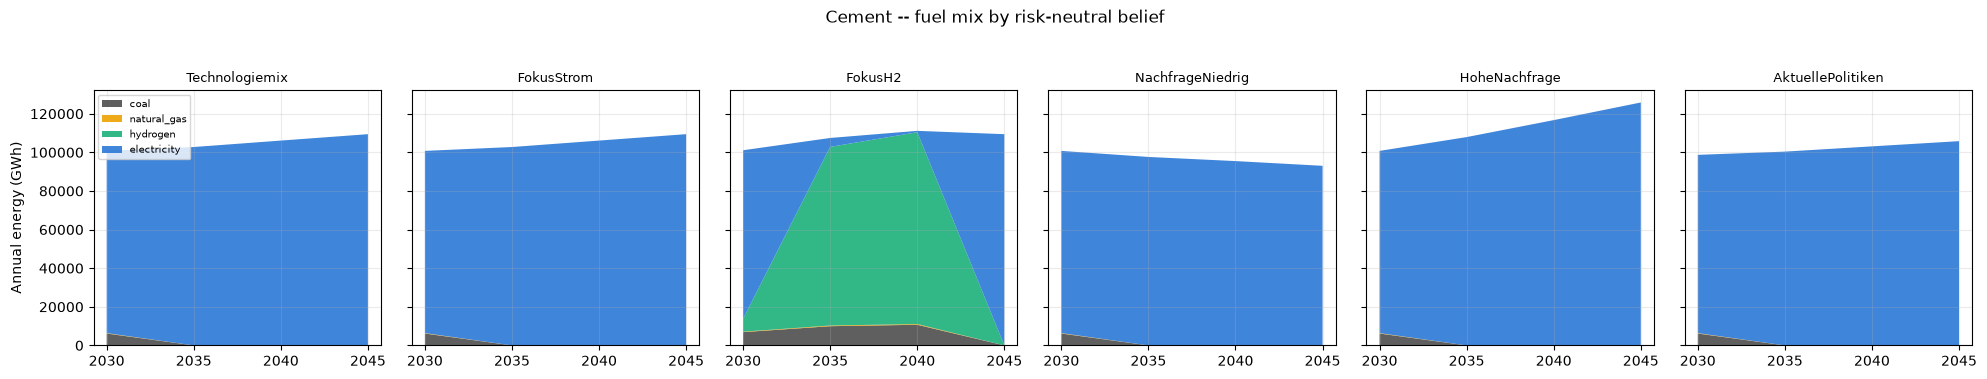

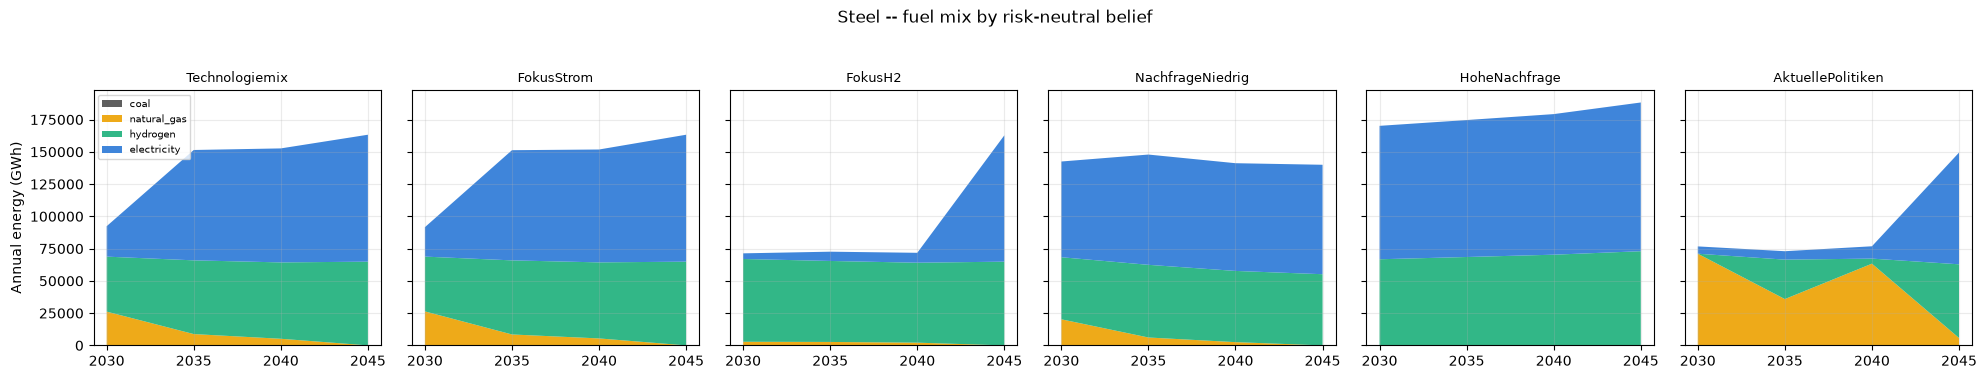

In [12]:
CARRIER_COLORS = {
    "electricity": "#2a78d6",
    "hydrogen": "#1baf7a",
    "natural_gas": "#eda100",
    "coal": "#4d4d4d",
}
CARRIER_ORDER = ["coal", "natural_gas", "hydrogen", "electricity"]


def plot_carrier_stack(ax, sub, title):
    pivot = sub.pivot_table(index="year", columns="carrier", values="MWh", aggfunc="mean")
    pivot = pivot.reindex(columns=CARRIER_ORDER, fill_value=0.0) / 1000
    ax.stackplot(
        pivot.index,
        [pivot[c] for c in CARRIER_ORDER],
        colors=[CARRIER_COLORS[c] for c in CARRIER_ORDER],
        labels=CARRIER_ORDER,
        alpha=0.9,
    )
    ax.set_title(title, fontsize=9)
    ax.grid(alpha=0.25)


for sector in ("cement", "steel"):
    fig, axes = plt.subplots(1, 6, figsize=(20, 3.6), sharey=True)
    subset = carriers[(carriers["sector"] == sector) & (carriers["decision_type"] == "risk-neutral")]
    for ax, decision in zip(axes, RN_DECISIONS):
        plot_carrier_stack(ax, subset[subset["decision"] == decision], decision)
    axes[0].set_ylabel("Annual energy (GWh)")
    axes[0].legend(fontsize=7, loc="upper left")
    fig.suptitle(f"{sector.capitalize()} -- fuel mix by risk-neutral belief", y=1.04)
    fig.tight_layout()
    plt.show()


**Key findings**

- Cement's fuel mix is flat for five of six beliefs -- coal shrinks from ~6% to ~0% but hydrogen never appears. FokusH2 is the outlier: hydrogen's share jumps from 7% (2030) to 86-89% (2035-2040), then drops back to 0% by 2045 as the plant reverts to its baseline route.
- Steel shows a much broader hydrogen transition: five of six beliefs land on 38-40% hydrogen share by 2045. AktuellePolitiken is the clear laggard -- it stays majority natural gas through 2035-2040 (peaking near 65% gas at 2040) before a late, compressed switch to hydrogen only by 2045.
- Natural gas phases out fastest under Technologiemix and FokusStrom (down to ~0% by 2040), confirming these beliefs assume the earliest full electrification-plus-hydrogen switch.

## Chart 3 -- Risk-averse decisions: fuel mix over time

WC Mean and WC Tail Risk each commit to one fixed technology path; the underlying `carriers` table keeps the full per-market breakdown (see `decision_type == "risk-averse"`), but the fuel *mix* a technology needs is driven by the technology itself, not by which market it lands in -- so each panel here averages across the 6 markets to show that mix cleanly, without 6 overlapping lines per fuel.

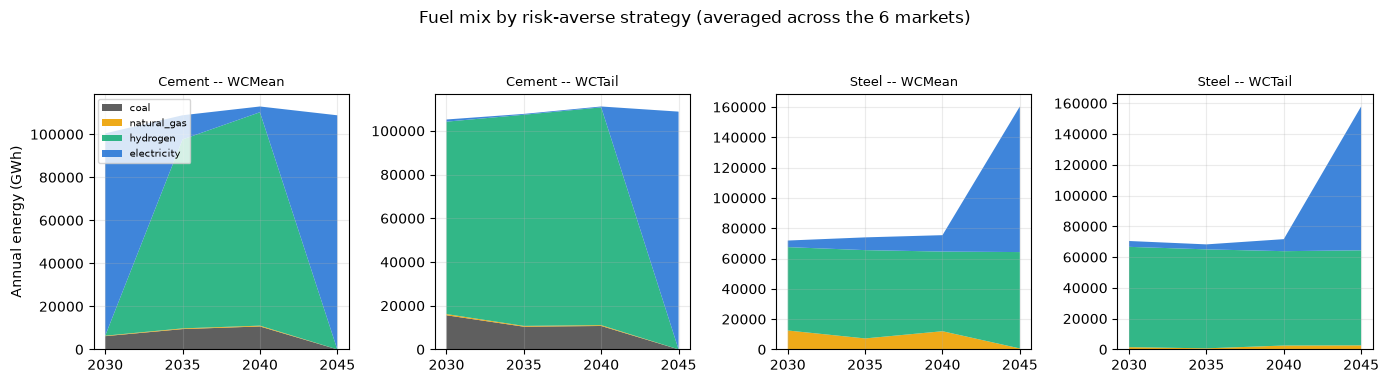

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=False)
for i, (sector, decision) in enumerate(
    (s, d) for s in ("cement", "steel") for d in RA_DECISIONS
):
    subset = carriers[
        (carriers["sector"] == sector)
        & (carriers["decision_type"] == "risk-averse")
        & (carriers["decision"] == decision)
    ]
    plot_carrier_stack(axes[i], subset, f"{sector.capitalize()} -- {decision}")
axes[0].set_ylabel("Annual energy (GWh)")
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle("Fuel mix by risk-averse strategy (averaged across the 6 markets)", y=1.05)
fig.tight_layout()
plt.show()


**Key findings**

- Both risk-averse strategies converge on high hydrogen shares once the technology switch happens: cement reaches 81-90% hydrogen share in the 2035-2040 window, steel reaches 70-94%.
- The more notable pattern is cement's demand *magnitude*, not its mix: WCMean's total annual demand drops to under 4% of its 2030 baseline during the mid-transition years (2035: ~11 GWh vs. ~94 GWh in 2030) before recovering to 94-126 GWh by 2045. WCTail shows the same dip even earlier. This is worth validating with the domain team -- whether it reflects a genuine capacity ramp-down on the transitional routes (R11a/R15a) or an input assumption worth revisiting.
- Steel's risk-averse strategies don't show this dip -- demand stays within the same order of magnitude across all years, growing steadily like the risk-neutral beliefs.

## Chart 4 -- One-look overview: risk-neutral trajectory vs. risk-averse exposure range

For each sector: the 6 risk-neutral "belief" trajectories as thin lines, plus the min-max band each risk-averse decision could land in depending on which market actually happens.

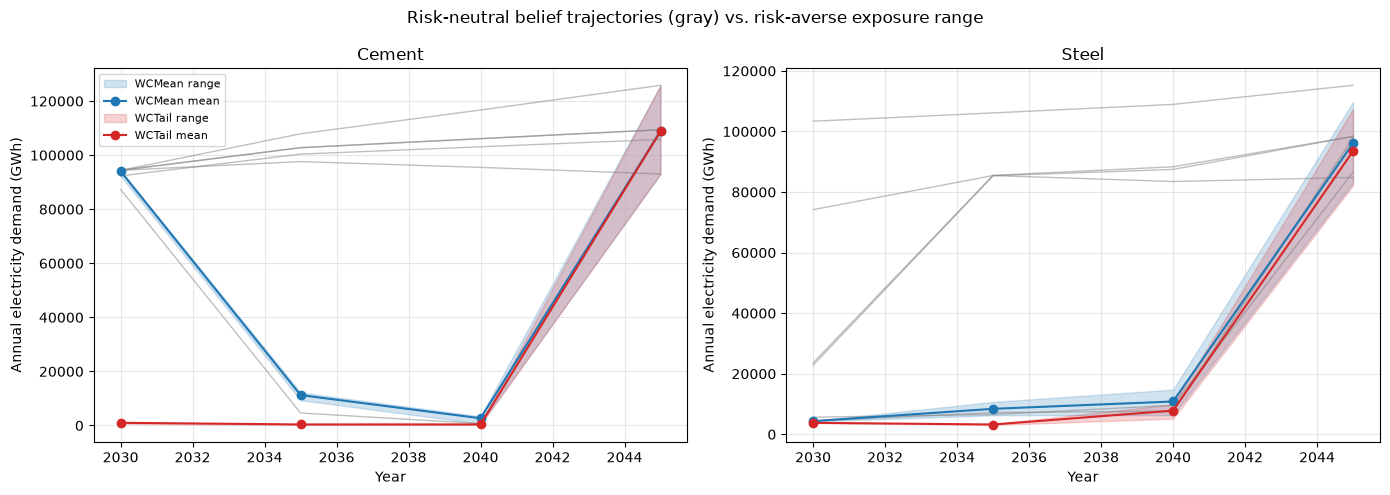

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, sector in zip(axes, ("cement", "steel")):
    rn = demand[(demand["sector"] == sector) & (demand["decision_type"] == "risk-neutral")]
    for decision, group in rn.groupby("decision"):
        group = group.sort_values("year")
        ax.plot(group["year"], group["total_MWh"] / 1000, color="gray", alpha=0.5, linewidth=1)

    ra = demand[(demand["sector"] == sector) & (demand["decision_type"] == "risk-averse")]
    colors = {"WCMean": "tab:blue", "WCTail": "tab:red"}
    for decision, group in ra.groupby("decision"):
        band = group.groupby("year")["total_MWh"].agg(["min", "max", "mean"]) / 1000
        ax.fill_between(band.index, band["min"], band["max"], alpha=0.2, color=colors[decision], label=f"{decision} range")
        ax.plot(band.index, band["mean"], color=colors[decision], marker="o", label=f"{decision} mean")

    ax.set_title(f"{sector.capitalize()}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual electricity demand (GWh)")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc="best")
fig.suptitle("Risk-neutral belief trajectories (gray) vs. risk-averse exposure range")
fig.tight_layout()
plt.show()


**Key findings**

- For steel, the risk-averse WCMean/WCTail bands sit mostly *below* the risk-neutral belief lines in 2035-2040 -- a risk-averse investor accepts materially lower electricity demand (and a slower ramp) during the transition in exchange for insurance against the worst-case market.
- Both sectors' risk-averse bands narrow sharply by 2045, converging into the same 85-126 GWh range as the risk-neutral beliefs -- so the "cost of being wrong about the market" mostly plays out in the 2030-2040 window, not at the 2045 horizon.
- The spread *within* a single risk-averse decision (its own min-max range across the 6 possible markets) peaks in 2040 for both sectors -- the fixed technology choice is most exposed to which market actually happens in the middle of the transition, not at either end. (For cement this shows as a large percentage swing, but the absolute magnitude at that point is small -- a few thousand MWh -- so read the percentage with that in mind.)

## Export the underlying table

In [15]:
export_path = PROJECT_ROOT / "data" / "output" / "technology_investment_demand_summary.xlsx"
with pd.ExcelWriter(export_path, engine="openpyxl") as writer:
    demand.to_excel(writer, sheet_name="Annual demand summary", index=False)
    demand.pivot_table(index=["sector", "decision", "year"], columns="market", values="total_MWh").to_excel(writer, sheet_name="Pivot (decision x market)")
    carriers.to_excel(writer, sheet_name="Carrier mix (long)", index=False)
    carriers.pivot_table(index=["sector", "decision", "market", "year"], columns="carrier", values="MWh").to_excel(writer, sheet_name="Carrier mix (wide)")
print(f"Saved: {export_path}")


Saved: /root/FLEXIMOD/data/output/technology_investment_demand_summary.xlsx
